# Create HAL config and shutter files

In [1]:
import os
import sys
from pathlib import Path
import numpy as np

MERCI_DIR  = Path(os.getcwd()).parent          # MERci/ (notebook lives in MERci/notebooks/)
SAMPLE_DIR = MERCI_DIR.parent                  # experiment root, e.g. LT048_sample_18/
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.acquisition.configs import (
    get_frame_table, get_color_sequence_name,
    create_shutter_file, create_hal_config,
)
from MERci.acquisition.display import print_frame_table, display_xml
from MERci.visualization       import visualize_shutter_sequence

In [2]:
SETTINGS_DIR = SAMPLE_DIR / "settings"
METADATA_DIR = SAMPLE_DIR / "metadata"
SETTINGS_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

MICROSCOPE    = "MF3"
HAL_TEMPLATE  = MERCI_DIR / "data" / "templates" / "hal-config-mf3-epi.xml"

# ── Imaging file format and camera settings ────────────────────────────
# FILE_TYPE options: ".zarr" (default), ".dax", ".tiff"
FILE_TYPE     = ".zarr"
EXPOSURE_TIME = 0.25      # seconds

print(f"SAMPLE_DIR   : {SAMPLE_DIR}")
print(f"SETTINGS_DIR : {SETTINGS_DIR}")
print(f"METADATA_DIR : {METADATA_DIR}")
print(f"HAL template : {HAL_TEMPLATE}")

SAMPLE_DIR   : c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time
SETTINGS_DIR : c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\settings
METADATA_DIR : c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\metadata
HAL template : c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\MERci\data\templates\hal-config-mf3-epi.xml


## create hal config for bits

Color sequence name: blkf4-488f2-560f25-650f25-750f25
frames                  color                   channel                 z                 

     0     1     2         488   nan   nan           3   nan   nan        0.00  0.00  0.00
     3     4     5         750   650   560           0     1     2        1.00  1.00  1.00
     6     7     8         750   650   560           0     1     2        2.00  2.00  2.00
     9    10    11         750   650   560           0     1     2        3.00  3.00  3.00
    12    13    14         750   650   560           0     1     2        4.00  4.00  4.00
    15    16    17         750   650   560           0     1     2        5.00  5.00  5.00
    18    19    20         750   650   560           0     1     2        6.00  6.00  6.00
    21    22    23         750   650   560           0     1     2        7.00  7.00  7.00
    24    25    26         750   650   560           0     1     2        8.00  8.00  8.00
    27    28    29         750   65

HAL config saved: c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\settings\hal-config-mf3-bits-blkf4-488f2-560f25-650f25-750f25.xml


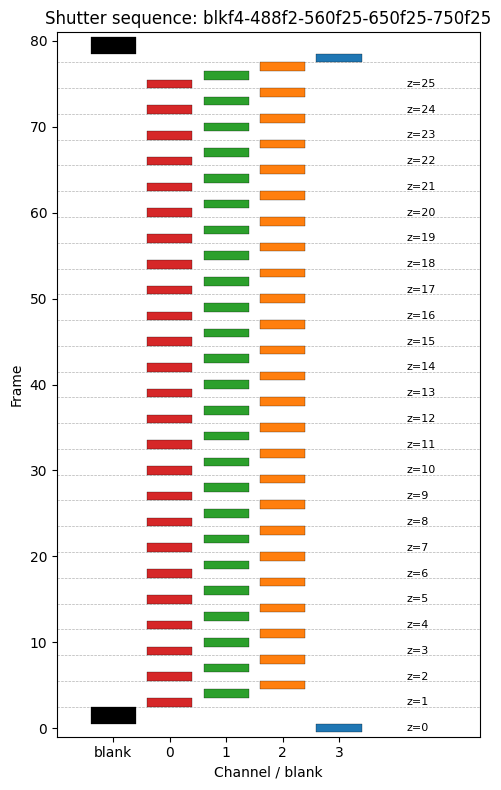

In [3]:
# ── Define imaging sequence ────────────────────────────────────────────
z_bead    = 0
z_min     = 1
z_max     = 25
z_step    = 1
z_pos     = np.arange(z_min, z_max+1, z_step) 
bead_seq  = [488, np.nan, np.nan]
color_seq = [750,    650,    560]
end_seq   = [488, np.nan, np.nan]

frame_table = get_frame_table(z_bead, bead_seq, color_seq, end_seq, z_pos, microscope=MICROSCOPE)
name        = get_color_sequence_name(frame_table)
print(f"Color sequence name: {name}")
print_frame_table(frame_table)

# ── Save frame table ────────────────────────────────────────────────────
ft_path = METADATA_DIR / f"frame_table_{name}.csv"
frame_table.to_csv(ft_path)
print(f"Frame table saved: {ft_path}")

# ── Write shutter file ──────────────────────────────────────────────────
shutter_name = f"shutter-{name}.xml"
shutter_path = SETTINGS_DIR / shutter_name
create_shutter_file(frame_table, shutter_path)
print(f"Shutter file saved: {shutter_path}")
display_xml(shutter_path)

# ── Write HAL config ────────────────────────────────────────────────────
hal_name   = f"hal-config-{MICROSCOPE.lower()}-bits-{name}.xml"
hal_output = SETTINGS_DIR / hal_name
create_hal_config(HAL_TEMPLATE, frame_table, shutter_name, hal_output,
                  file_type=FILE_TYPE, exposure_time=EXPOSURE_TIME)
print(f"HAL config saved: {hal_output}")
display_xml(hal_output)

# ── Visualise shutter sequence ──────────────────────────────────────────
visualize_shutter_sequence(
    frame_table,
    title=f"Shutter sequence: {name}",
    save_path=METADATA_DIR / f"shutter_sequence_{name}.png",
)

## create hal config for cells

Color sequence name: 405f25-488f2
frames      color       channel      z     

     0         488           3        0.00
     1         405           4        1.00
     2         405           4        2.00
     3         405           4        3.00
     4         405           4        4.00
     5         405           4        5.00
     6         405           4        6.00
     7         405           4        7.00
     8         405           4        8.00
     9         405           4        9.00
    10         405           4       10.00
    11         405           4       11.00
    12         405           4       12.00
    13         405           4       13.00
    14         405           4       14.00
    15         405           4       15.00
    16         405           4       16.00
    17         405           4       17.00
    18         405           4       18.00
    19         405           4       19.00
    20         405           4       20.00
    21         405

HAL config saved: c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\settings\hal-config-mf3-cells-405f25-488f2.xml


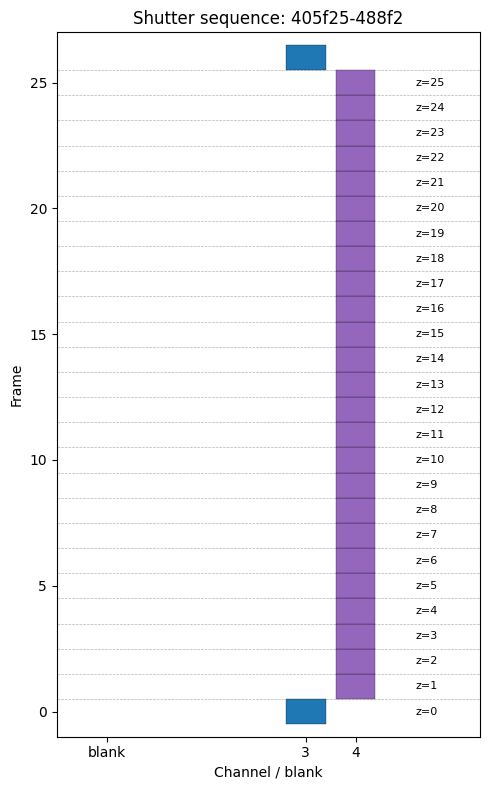

In [4]:
# ── Define imaging sequence ────────────────────────────────────────────
z_bead    = 0
z_min     = 1
z_max     = 25
z_step    = 1
z_pos     = np.arange(z_min, z_max+1, z_step) 
bead_seq  = [488]
color_seq = [405]
end_seq   = [488]

frame_table = get_frame_table(z_bead, bead_seq, color_seq, end_seq, z_pos, microscope=MICROSCOPE)
name        = get_color_sequence_name(frame_table)
print(f"Color sequence name: {name}")
print_frame_table(frame_table)

# ── Save frame table ────────────────────────────────────────────────────
ft_path = METADATA_DIR / f"frame_table_{name}.csv"
frame_table.to_csv(ft_path)
print(f"Frame table saved: {ft_path}")

# ── Write shutter file ──────────────────────────────────────────────────
shutter_name = f"shutter-{name}.xml"
shutter_path = SETTINGS_DIR / shutter_name
create_shutter_file(frame_table, shutter_path)
print(f"Shutter file saved: {shutter_path}")
display_xml(shutter_path)

# ── Write HAL config ────────────────────────────────────────────────────
hal_name   = f"hal-config-{MICROSCOPE.lower()}-cells-{name}.xml"
hal_output = SETTINGS_DIR / hal_name
create_hal_config(HAL_TEMPLATE, frame_table, shutter_name, hal_output,
                  file_type=FILE_TYPE, exposure_time=EXPOSURE_TIME)
print(f"HAL config saved: {hal_output}")
display_xml(hal_output)

# ── Visualise shutter sequence ──────────────────────────────────────────
visualize_shutter_sequence(
    frame_table,
    title=f"Shutter sequence: {name}",
    save_path=METADATA_DIR / f"shutter_sequence_{name}.png",
)